In [1]:
# CE baseline without OOD

# GLOBAL OOD CONVENTION

GLOBAL OOD STANDARD USED EVERYWHERE IN THIS CODEBASE:

    ID  = 0
    OOD = 1

    low score  -> likely ID
    high score -> likely OOD

This convention MUST NEVER change.

# IMPORTS

In [2]:
import os
import copy
from torch.optim import AdamW
from transformers import AutoTokenizer, get_linear_schedule_with_warmup

from torch.utils.data import DataLoader

from src.data import *
from src.losses import *
from src.trainer import *
from src.model_forward import IntentClassifier

import src.metrics as metrics

from src.helpers import *
from src.print import *

# CONFIG

In [3]:
CONFIG = {
    "EXPERIMENT_NAME": "CE-HOOD",

    # Model
    "MODEL_NAME": "./bert-base-uncased",

    # Training
    "EPOCHS": 10,
    "BATCH_SIZE": 64,
    "LR": 2e-5,
    "MAX_LEN": 64,
    "WEIGHT_DECAY": 0.01,
    "MAX_GRAD_NORM": 1.0,

    # Loss
    "loss_fn": composite_loss(["ce", "energy"]),

    # Energy parameters
    "PARAMS": {
        "energy_margin_id_sigma": 1.2,
        "energy_margin_ood_sigma": 2.8,
    },

    # Schedule
    "LOSS_SCHEDULE": {
        1: {"ce": 1.0, "energy": 0.0},
        2: {"ce": 1.0, "energy": 0.0},
        3: {"ce": 1.0, "energy": 0.0},
        4: {"ce": 1.0, "energy": 0.0},
        5: {"ce": 1.0, "energy": 0.0},
        6: {"ce": 1.0, "energy": 0.0},
        7: {"ce": 1.0, "energy": 0.0},
        8: {"ce": 1.0, "energy": 0.0},
        9: {"ce": 1.0, "energy": 0.0},
        10: {"ce": 1.0, "energy": 0.0},
    },

    # DataLoader
    "NUM_WORKERS": 4,
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "PIN_MEMORY": torch.cuda.is_available(),
    "USE_FAST": torch.cuda.is_available(),
    "USE_AMP": torch.cuda.is_available(),

}

HARD_OOD_TXT = Path("data/clinc_ood_train.txt")

# DEVICE

In [4]:
print(f"Using device: {CONFIG['DEVICE']}")

if CONFIG['DEVICE'].type == "cuda":
    torch.backends.cuda.matmul.fp32_precision = 'ieee'   
    torch.backends.cudnn.fp32_precision = 'ieee'
    torch.backends.cudnn.benchmark = True  
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"Memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA version: {torch.version.cuda}")


Using device: cuda
CUDA device: NVIDIA RTX A4000
CUDA memory: 16.8 GB
Memory allocated: 0.00 GB
PyTorch version: 2.9.0+cu128
CUDA version: 12.8


# SEED

In [5]:
SEED         = 42
from src.seed import set_seed, seed_worker
g = torch.Generator()
g.manual_seed(SEED)
set_seed(SEED)

Global seed set to: 42


## ADDITIONAL OOD

In [6]:
hard_ood_samples = load_hard_ood_from_txt(HARD_OOD_TXT)


HARD OOD LOADED
File: data/clinc_ood_train.txt
Total HARD OOD samples: 250
Avg words per sample: 7.33

Examples:
  [0] how much is an overdraft fee for bank
  [1] why are exponents preformed before multiplication in the order of operations
  [2] what size wipers does this car take
  [3] where is the dipstick
  [4] how much is 1 share of aapl


# DATASETS

In [7]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['MODEL_NAME'], use_fast=CONFIG['USE_FAST'])

In [8]:
splits, label2id = load_clinc150(include_ood=True)
id2label = {v: k for k, v in label2id.items()}
num_classes = len(label2id)

In [9]:
train_dataset = build_dataset(
    split_samples=splits["train"],
    label2id=label2id,
    tokenizer=tokenizer,
    max_length=CONFIG['MAX_LEN'],
    
    include_ood=True, # with OOD
    hard_ood_samples=hard_ood_samples, # with HOOD
)

val_dataset = build_dataset(
    split_samples=splits["val"],
    label2id=label2id,
    tokenizer=tokenizer,
    max_length=CONFIG['MAX_LEN'],
    include_ood=True,
    hard_ood_samples=None,
)

test_dataset = build_dataset(
    split_samples=splits["test"],
    label2id=label2id,
    tokenizer=tokenizer,
    max_length=CONFIG['MAX_LEN'],
    include_ood=True,
    hard_ood_samples=None,
)

In [10]:
dataset_summary(train_dataset, 'TRAIN DATASET')

TRAIN DATASET
  Total samples: 15350
  ID samples: 15000
  OOD samples: 350
  Unique ID labels: 150


In [11]:
dataset_summary(val_dataset, 'VALIDATION DATASET')

VALIDATION DATASET
  Total samples: 3100
  ID samples: 3000
  OOD samples: 100
  Unique ID labels: 150


In [12]:
dataset_summary(test_dataset, 'TEST DATASET')

TEST DATASET
  Total samples: 5500
  ID samples: 4500
  OOD samples: 1000
  Unique ID labels: 150


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=CONFIG['PIN_MEMORY'],
    persistent_workers=CONFIG['NUM_WORKERS'] > 0, # Keep workers alive between epochs
    worker_init_fn=seed_worker, # Seed every worker deterministically
    generator=g, # Deterministic shuffling
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=CONFIG['PIN_MEMORY'],
    persistent_workers=CONFIG['NUM_WORKERS'] > 0, # Keep workers alive between epochs
    worker_init_fn=seed_worker, # Seed every worker deterministically
    generator=g, # Deterministic shuffling
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=CONFIG['PIN_MEMORY'],
    persistent_workers=CONFIG['NUM_WORKERS'] > 0, # Keep workers alive between epochs
    worker_init_fn=seed_worker, # Seed every worker deterministically
    generator=g, # Deterministic shuffling
)



# MODEL & OPTIMIZER & SCHEDULER



In [14]:
model = IntentClassifier(
    CONFIG['MODEL_NAME'],
    num_classes
).to(CONFIG['DEVICE'])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ./bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
optimizer = AdamW(model.parameters(), lr=CONFIG['LR'], weight_decay=CONFIG['WEIGHT_DECAY'])
scaler = torch.amp.GradScaler(enabled=CONFIG['USE_AMP'])
total_steps = len(train_loader) * CONFIG['EPOCHS']
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# TRAINING LOOP

In [16]:
state_save = {} # FOR DEL

all_train_records = {}
all_train_metrics = {}
all_train_stats = {}
all_val_metrics = {}

epoch_stats = None
prev_epoch_stats = None

best_state = None
best_epoch = 0
best_score = 0

for epoch in range(1, CONFIG['EPOCHS'] + 1):

    print("\n" + "=" * 80)
    print(f"EPOCH {epoch} / {CONFIG['EPOCHS']}")

    config = build_epoch_config(
        epoch=epoch,
        epoch_stats=prev_epoch_stats,
        CONFIG=CONFIG
    )

    epoch_metrics, epoch_records = train_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        config=config,
        CONFIG=CONFIG,
        scaler=scaler,
        logger= True,
        epoch=epoch,
        id2label=id2label,
    )

    epoch_stats = compute_epoch_stats(epoch_records)
    prev_epoch_stats = epoch_stats

    print_train_metrics(epoch_metrics)
    print_epoch_stats(epoch_stats)

    val_metrics = evaluate(
        model,
        val_loader,
        CONFIG['DEVICE'],
        metrics,
    )


    print("\nVALIDATION RESULTS")
    print("-" * 40)
    for k, v in val_metrics.items():
        print(f"   {k:20s}: {v:.4f}")

    all_train_metrics[epoch] = epoch_metrics
    all_train_stats[epoch] = epoch_stats
    all_val_metrics[epoch] = val_metrics

    if epoch >= 4:
        state_save[epoch] = copy.deepcopy(model.state_dict())
    
    score = val_metrics['auroc'] + val_metrics['aupr'] + (1 - val_metrics['fpr95'])
    
    if score > best_score:
        best_score = score
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        print(f"\nNew best model!\n")


EPOCH 1 / 10


TRAIN:   0%|          | 0/240 [00:00<?, ?it/s]

   ce_weight           : 1.0000
   energy_weight       : 0.0000
   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Ce          : 4.5340 × 1.0 = 4.5340
   Energy      : 0.0000 × 0.0 = 0.0000

   LOSS        : 4.5349
   ──────────────────────────────────────────────────

   Energy:
      ID    : -5.0835 ± 0.0520
      OOD   : -5.0876 ± 0.0420
      Gap   : -0.0041
      AUROC : 0.4399
   Energy percentiles:
      Gap(5%) : -0.1424  (ID p95=-5.0257, OOD p5=-5.1681)
      Gap(10%): -0.1171 (ID p90=-5.0332, OOD p10=-5.1503)
   Confidence:
      ID    : 0.0209
      OOD   : 0.0176
      Gap   : 0.0033
      Correct vs Wrong: 0.0400 / 0.0165
   Entropy:
      ID    : 4.9331
      OOD   : 4.9431
      Gap   : 0.0100
   ID accuracy: 0.1864


EVAL:   0%|          | 0/49 [00:00<?, ?it/s]


VALIDATION RESULTS
----------------------------------------
   accuracy            : 0.7763
   macro_f1            : 0.7610
   macro_precision     : 0.8181
   macro_recall        : 0.7763
   auroc               : 0.8143
   aupr                : 0.1779
   fpr95               : 0.6480

New best model!


EPOCH 2 / 10


...


VALIDATION RESULTS
----------------------------------------
   accuracy            : 0.9660
   macro_f1            : 0.9658
   macro_precision     : 0.9684
   macro_recall        : 0.9660
   auroc               : 0.9719
   aupr                : 0.6667
   fpr95               : 0.1093

EPOCH 10 / 10


TRAIN:   0%|          | 0/240 [00:00<?, ?it/s]

   ce_weight           : 1.0000
   energy_weight       : 0.0000
   energy_margin_id    : -9.0489
   energy_margin_ood   : -5.7883
   energy_margin_id_sigmastd: 0.4663
   energy_margin_ood_sigmastd: 2.4196
   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Ce          : 0.0197 × 1.0 = 0.0197
   Energy      : 0.0000 × 0.0 = 0.0000

   LOSS        : 0.0197
   ──────────────────────────────────────────────────

   Energy:
      ID    : -9.3406 ± 0.3833
      OOD   : -6.2672 ± 0.8863
      Gap   : 3.0734
      AUROC : 0.9932
   Energy percentiles:
      Gap(5%) : 0.3060  (ID p95=-8.6635, OOD p5=-8.3575)
      Gap(10%): 1.2590 (ID p90=-8.8812, OOD p10=-7.6222)
   Confidence:
      ID    : 0.9826
      OOD   : 0.4182
      Gap   : 0.5644
      Correct vs Wrong: 0.9828 / 0.7699
   Entropy:
      ID    : 0.1639
      OOD   : 2.9715
      Gap   : 2.8076
   ID accuracy: 0.9993


EVAL:   0%|          | 0/49 [00:00<?, ?it/s]


VALIDATION RESULTS
----------------------------------------
   accuracy            : 0.9677
   macro_f1            : 0.9675
   macro_precision     : 0.9700
   macro_recall        : 0.9677
   auroc               : 0.9721
   aupr                : 0.6709
   fpr95               : 0.1103


In [17]:
print(f" BEST EPOCH: {best_epoch}")

 BEST EPOCH: 6


# FINAL TEST EVALUATION

In [18]:
print("\n" + "=" * 80)
print("FINAL TEST EVALUATION")
print("=" * 80)

model.load_state_dict(best_state)
model.eval()

test_metrics = evaluate(
    model,
    test_loader,
    CONFIG['DEVICE'],
    metrics,
)

for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"{k:20s}: {v:.4f}")
    else:
        print(f"{k:20s}: {v}")


FINAL TEST EVALUATION


EVAL:   0%|          | 0/86 [00:00<?, ?it/s]

accuracy            : 0.9607
macro_f1            : 0.9605
macro_precision     : 0.9622
macro_recall        : 0.9607
auroc               : 0.9755
aupr                : 0.9120
fpr95               : 0.1187


In [19]:
save_experiment_log(
    config=CONFIG,
    all_train_metrics=all_train_metrics,
    all_train_stats=all_train_stats,
    all_val_metrics=all_val_metrics,
    test_metrics=test_metrics,
    output_dir="experiment_logs"
)

Experiment log saved to: experiment_logs/CE-HOOD_20260530_184656.json


PosixPath('experiment_logs/CE-HOOD_20260530_184656.json')

# GRAPHICS

In [20]:
import matplotlib.pyplot as plt

# Convert to DataFrames for easier plotting
train_loss_df = pd.DataFrame([
    {**metrics, 'epoch': epoch}
    for epoch, metrics in all_train_metrics.items()
]).set_index('epoch')

train_stats_df = pd.DataFrame([
    {**stats, 'epoch': epoch}
    for epoch, stats in all_train_stats.items()
]).set_index('epoch')

val_df = pd.DataFrame([
    {**metrics, 'epoch': epoch}
    for epoch, metrics in all_val_metrics.items()
]).set_index('epoch')

# Get loss component names dynamically
loss_components = [col for col in train_loss_df.columns if col.endswith('_loss') and not col.endswith('_weighted')]
loss_component_names = [c.replace('_loss', '').capitalize() for c in loss_components]
# Find best epoch for each metric
best_auroc_epoch = val_df['auroc'].idxmax()
best_f1_epoch = val_df['macro_f1'].idxmax()
best_acc_epoch = val_df['accuracy'].idxmax()

print("BEST TRAIN VALIDATION RESULTS:")
print(f"\n    Best AUROC:     {val_df['auroc'].max():.4f} (Epoch {best_auroc_epoch})")
print(f"    Best Macro F1:  {val_df['macro_f1'].max():.4f} (Epoch {best_f1_epoch})")
print(f"    Best Accuracy:  {val_df['accuracy'].max():.4f} (Epoch {best_acc_epoch})")
print(f"    Best FPR95:     {val_df['fpr95'].min():.4f} (Epoch {val_df['fpr95'].idxmin()})")

BEST TRAIN VALIDATION RESULTS:

    Best AUROC:     0.9739 (Epoch 6)
    Best Macro F1:  0.9675 (Epoch 10)
    Best Accuracy:  0.9677 (Epoch 5)
    Best FPR95:     0.0983 (Epoch 6)


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to DataFrames for easier plotting
train_loss_df = pd.DataFrame([
    {**metrics, 'epoch': epoch}
    for epoch, metrics in all_train_metrics.items()
]).set_index('epoch')

train_stats_df = pd.DataFrame([
    {**stats, 'epoch': epoch}
    for epoch, stats in all_train_stats.items()
]).set_index('epoch')

val_df = pd.DataFrame([
    {**metrics, 'epoch': epoch}
    for epoch, metrics in all_val_metrics.items()
]).set_index('epoch')

# Get loss component names dynamically
loss_components = [col for col in train_loss_df.columns if col.endswith('_loss') and not col.endswith('_weighted')]
loss_component_names = [c.replace('_loss', '').capitalize() for c in loss_components]

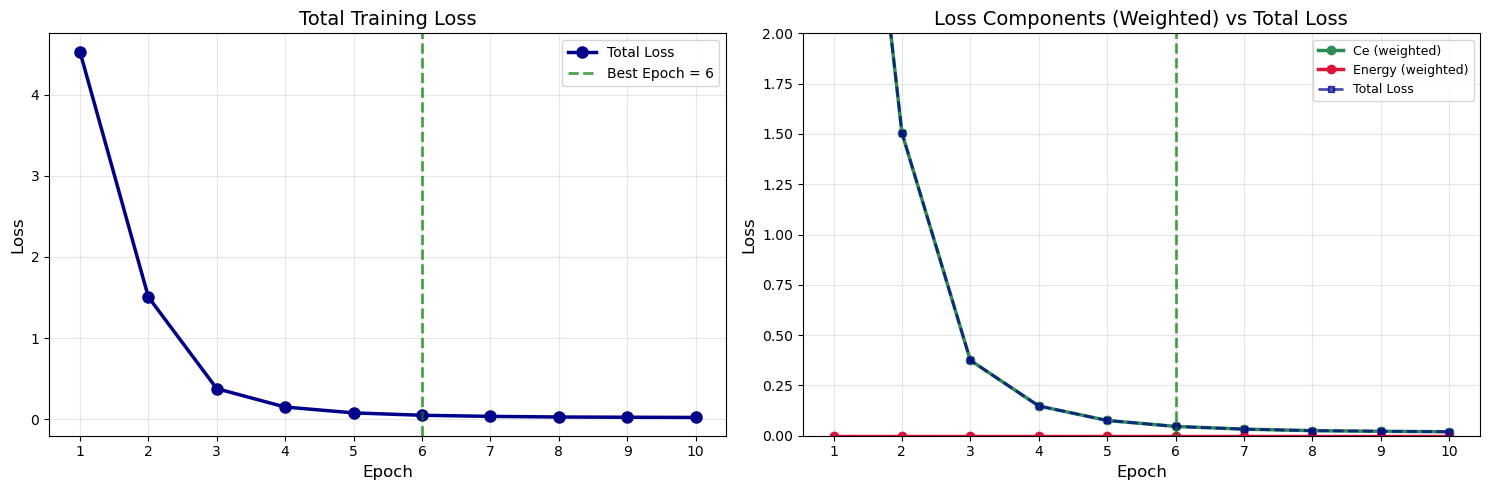

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs = train_loss_df.index.tolist()

# ============================================================
# Plot 1: Total Loss только (чистый общий лосс)
# ============================================================
axes[0].plot(epochs, train_loss_df['train_loss'], marker='o', linestyle='-', linewidth=2.5, markersize=8,
             label='Total Loss', color='darkblue')
if best_epoch is not None:
    axes[0].axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7, 
                    label=f'Best Epoch = {best_epoch}')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Total Training Loss', fontsize=14)
axes[0].set_xticks(epochs)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ============================================================
# Plot 2: Все weighted лосс компоненты + общий (для сравнения)
# ============================================================

# Get all weighted loss components
weighted_cols = [col for col in train_loss_df.columns if col.endswith('_loss_weighted')]

# Color map for different components - яркие, контрастные цвета
colors = ['#2E8B57', '#DC143C', '#FF8C00', '#8B008B', '#B8860B', 
          '#FF69B4', '#4169E1', '#20B2AA', '#FF4500', '#6A5ACD']

# Plot each weighted component - жирные линии
for i, col in enumerate(weighted_cols):
    name = col.replace('_loss_weighted', '').capitalize()
    axes[1].plot(epochs, train_loss_df[col], 
                 marker='o', 
                 linestyle='-', 
                 linewidth=2.5, 
                 markersize=6,
                 label=f'{name} (weighted)', 
                 color=colors[i % len(colors)])

# Plot total loss for reference - синий, заметный но не доминирующий
axes[1].plot(epochs, train_loss_df['train_loss'], 
             marker='s', 
             linestyle='--', 
             linewidth=2, 
             markersize=5,
             label='Total Loss', 
             color='darkblue', 
             alpha=0.7)

if best_epoch is not None:
    axes[1].axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Components (Weighted) vs Total Loss', fontsize=14)
axes[1].set_xticks(epochs)

# Устанавливаем границы
y_max = 2.0
# Находим минимальное значение среди всех потерь
all_loss_values = []
for col in weighted_cols:
    all_loss_values.extend(train_loss_df[col])
all_loss_values.extend(train_loss_df['train_loss'])

loss_min = min(all_loss_values)
# Нижняя граница: либо 0, либо чуть ниже минимального значения
y_min = max(0, loss_min - 0.1)

axes[1].set_ylim([y_min, y_max])

# Легенда справа, если много компонентов
if len(weighted_cols) > 5:
    axes[1].legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
else:
    axes[1].legend(loc='best', fontsize=9)

axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

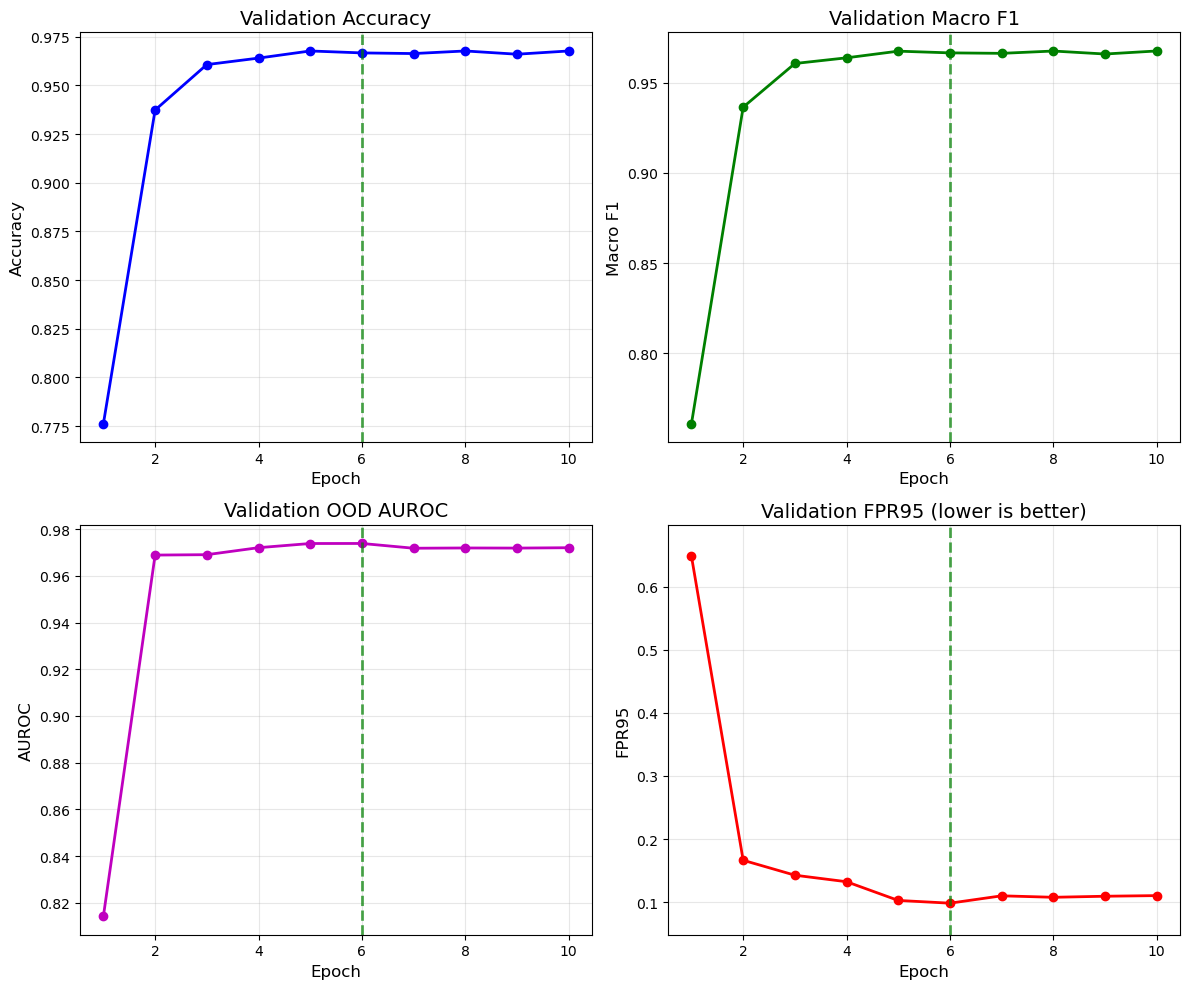

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Функция для автоматического масштабирования с учетом динамики
def set_auto_ylim(ax, data, min_bound=0, max_bound=1, padding=0.05):
    data_min = data.min()
    data_max = data.max()
    data_range = data_max - data_min
    
    # Если диапазон очень маленький, увеличиваем отступ
    if data_range < 0.05:
        padding = 0.2
    
    y_min = max(min_bound, data_min - padding * data_range if data_range > 0 else data_min - padding)
    y_max = min(max_bound, data_max + padding * data_range if data_range > 0 else data_max + padding)
    
    ax.set_ylim([y_min, y_max])

# Accuracy
axes[0, 0].plot(val_df.index, val_df['accuracy'], 'b-o', linewidth=2, markersize=6)
if best_epoch is not None:
    axes[0, 0].axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best Epoch = {best_epoch}')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Validation Accuracy', fontsize=14)
set_auto_ylim(axes[0, 0], val_df['accuracy'], min_bound=0.5, max_bound=1.0, padding=0.05)
axes[0, 0].grid(True, alpha=0.3)

# Macro F1
axes[0, 1].plot(val_df.index, val_df['macro_f1'], 'g-o', linewidth=2, markersize=6)
if best_epoch is not None:
    axes[0, 1].axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Macro F1', fontsize=12)
axes[0, 1].set_title('Validation Macro F1', fontsize=14)
set_auto_ylim(axes[0, 1], val_df['macro_f1'], min_bound=0.5, max_bound=1.0, padding=0.05)
axes[0, 1].grid(True, alpha=0.3)

# AUROC
axes[1, 0].plot(val_df.index, val_df['auroc'], 'm-o', linewidth=2, markersize=6)
if best_epoch is not None:
    axes[1, 0].axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('AUROC', fontsize=12)
axes[1, 0].set_title('Validation OOD AUROC', fontsize=14)
set_auto_ylim(axes[1, 0], val_df['auroc'], min_bound=0.5, max_bound=1.0, padding=0.05)
axes[1, 0].grid(True, alpha=0.3)

# FPR95 (lower is better)
axes[1, 1].plot(val_df.index, val_df['fpr95'], 'r-o', linewidth=2, markersize=6)
if best_epoch is not None:
    axes[1, 1].axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('FPR95', fontsize=12)
axes[1, 1].set_title('Validation FPR95 (lower is better)', fontsize=14)
# Для FPR95 показываем динамику от минимального значения
y_min_fpr = max(0, val_df['fpr95'].min() - 0.05)
y_max_fpr = min(1.0, val_df['fpr95'].max() + 0.05)
# Если значения маленькие, показываем детальнее
if val_df['fpr95'].max() < 0.3:
    y_max_fpr = val_df['fpr95'].max() + 0.05
axes[1, 1].set_ylim([y_min_fpr, y_max_fpr])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

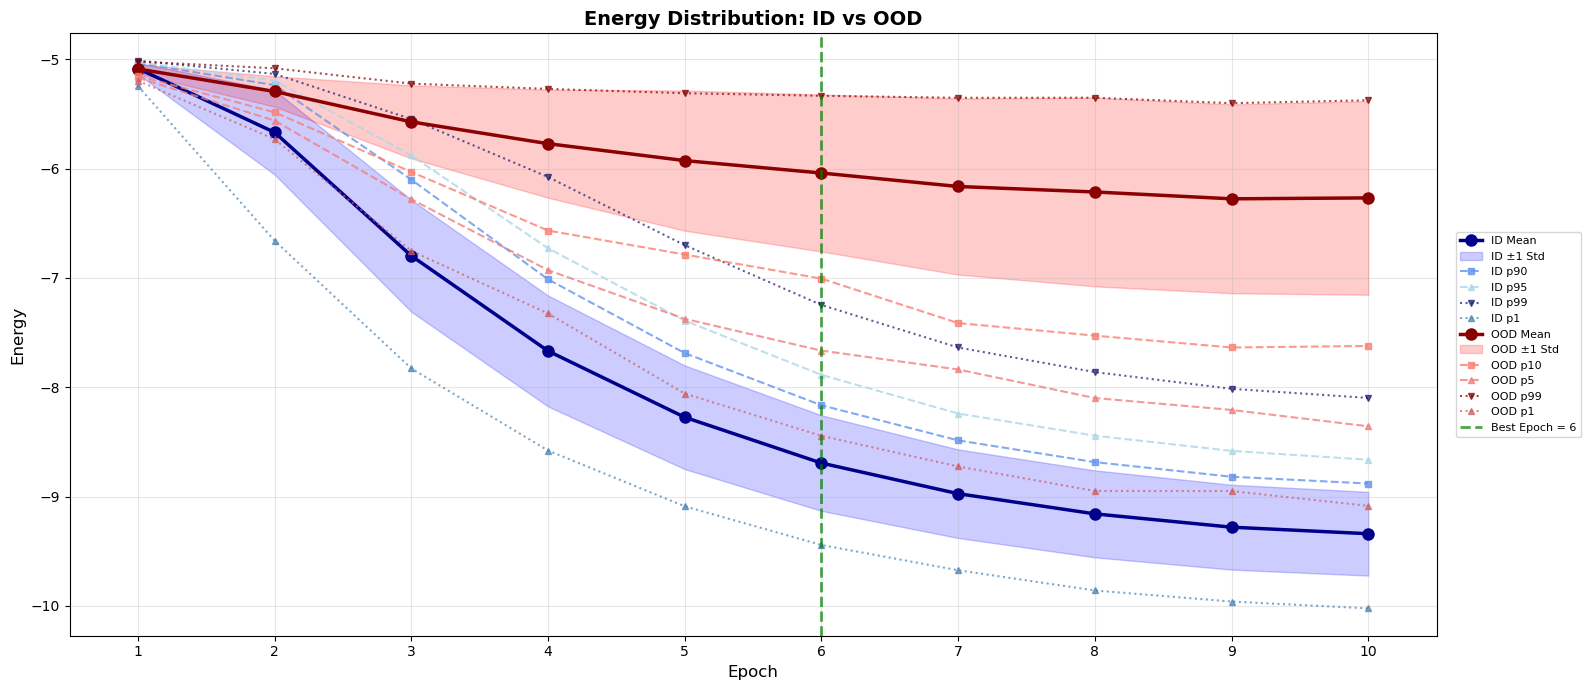

In [24]:
fig, ax = plt.subplots(figsize=(16, 7))

epochs = train_stats_df.index.tolist()

# ID Energy: mean + std
ax.plot(epochs, train_stats_df['energy_id_mean'], 'o-', linewidth=2.5, markersize=8,
        label='ID Mean', color='darkblue')
ax.fill_between(epochs,
                 train_stats_df['energy_id_mean'] - train_stats_df['energy_id_std'],
                 train_stats_df['energy_id_mean'] + train_stats_df['energy_id_std'],
                 alpha=0.2, color='blue', label='ID ±1 Std')

# ID percentiles
ax.plot(epochs, train_stats_df['energy_id_p90'], '--s', linewidth=1.5, markersize=5,
        label='ID p90', color='cornflowerblue', alpha=0.8)
ax.plot(epochs, train_stats_df['energy_id_p95'], '--^', linewidth=1.5, markersize=5,
        label='ID p95', color='lightblue', alpha=0.8)
ax.plot(epochs, train_stats_df['energy_id_p99'], ':', linewidth=1.5, markersize=5,
        label='ID p99', color='midnightblue', alpha=0.7, marker='v')
ax.plot(epochs, train_stats_df['energy_id_p1'], ':', linewidth=1.5, markersize=5,
        label='ID p1', color='steelblue', alpha=0.7, marker='^')

# OOD Energy: mean + std
ax.plot(epochs, train_stats_df['energy_ood_mean'], 'o-', linewidth=2.5, markersize=8,
        label='OOD Mean', color='darkred')
ax.fill_between(epochs,
                 train_stats_df['energy_ood_mean'] - train_stats_df['energy_ood_std'],
                 train_stats_df['energy_ood_mean'] + train_stats_df['energy_ood_std'],
                 alpha=0.2, color='red', label='OOD ±1 Std')

# OOD percentiles
ax.plot(epochs, train_stats_df['energy_ood_p10'], '--s', linewidth=1.5, markersize=5,
        label='OOD p10', color='salmon', alpha=0.8)
ax.plot(epochs, train_stats_df['energy_ood_p05'], '--^', linewidth=1.5, markersize=5,
        label='OOD p5', color='lightcoral', alpha=0.8)
ax.plot(epochs, train_stats_df['energy_ood_p99'], ':', linewidth=1.5, markersize=5,
        label='OOD p99', color='maroon', alpha=0.7, marker='v')
ax.plot(epochs, train_stats_df['energy_ood_p01'], ':', linewidth=1.5, markersize=5,
        label='OOD p1', color='indianred', alpha=0.7, marker='^')

# Вертикальная линия для лучшей эпохи
if best_epoch is not None:
    ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best Epoch = {best_epoch}')
    
    # Добавляем затенение для выделения области лучшей эпохи (опционально)
    # ax.axvspan(best_epoch - 0.5, best_epoch + 0.5, alpha=0.1, color='green')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_title('Energy Distribution: ID vs OOD', fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), ncol=1, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xticks(epochs)
ax.set_xlim(0.5, len(epochs) + 0.5)

# Автоматическое вычисление границ y_min и y_max
# Собираем все данные, которые отображаются на графике
all_values = []

# Добавляем средние значения и стандартные отклонения
all_values.extend(train_stats_df['energy_id_mean'])
all_values.extend(train_stats_df['energy_id_mean'] - train_stats_df['energy_id_std'])
all_values.extend(train_stats_df['energy_id_mean'] + train_stats_df['energy_id_std'])
all_values.extend(train_stats_df['energy_ood_mean'])
all_values.extend(train_stats_df['energy_ood_mean'] - train_stats_df['energy_ood_std'])
all_values.extend(train_stats_df['energy_ood_mean'] + train_stats_df['energy_ood_std'])

# Добавляем все перцентили
percentile_columns = ['energy_id_p90', 'energy_id_p95', 'energy_id_p99', 'energy_id_p1',
                      'energy_ood_p10', 'energy_ood_p05', 'energy_ood_p99', 'energy_ood_p01']

for col in percentile_columns:
    if col in train_stats_df.columns:
        all_values.extend(train_stats_df[col])

# Вычисляем min и max с небольшим отступом (5% от размаха)
data_min = min(all_values)
data_max = max(all_values)
data_range = data_max - data_min
y_min = data_min - 0.05 * data_range
y_max = data_max + 0.05 * data_range

ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()